# One Race, Properly

The goal here is not to produce a chart. It is to find out whether the *data wrangling*
is fun for you, because that is what this project actually is. Roughly 80% of F1
analytics is deciding which lap times are allowed to mean something.

By the end you will have:

1. A cleaned set of lap times, and an honest account of what was thrown away
2. Race pace with the fuel effect removed — the number that tells you who was actually fast
3. A check that the answer survives the assumptions used to produce it
4. Tyre degradation curves — the input a strategy simulator needs
5. Teammate pace gaps — the atom of a driver-vs-car model

Those last two are the seeds of the two directions you picked: the race-day companion
and the driver-vs-car decomposition.

In [1]:
import sys, warnings
warnings.filterwarnings("ignore")
sys.path.insert(0, "..")

import matplotlib.pyplot as plt
import pandas as pd

from f1lab import clean, pace, plots

plots.use_dark_theme()
pd.set_option("display.width", 160)

# Change these two lines to look at any race from 2018 onward.
YEAR, GP = 2024, "Hungary"

## 1. Load the session

The first load for a race pulls a few MB from the F1 timing API and takes a while.
Every load after that comes from `cache/` and is instant. Never run FastF1 without
the cache on — you will get rate-limited and you will deserve it.

In [2]:
session = clean.load_race(YEAR, GP, "R")

print(f"{session.event['EventName']} {YEAR}")
print(f"Circuit:    {session.event['Location']}")
print(f"Race laps:  {session.total_laps}")
print(f"Raw laps in timing data: {len(session.laps)}")

core           INFO 	Loading data for Hungarian Grand Prix - Race [v3.8.3]


req            INFO 	Using cached data for session_info


req            INFO 	Using cached data for driver_info


req            INFO 	Using cached data for session_status_data


req            INFO 	Using cached data for lap_count


...

req            INFO 	Using cached data for timing_app_data


core           INFO 	Processing timing data...


req            INFO 	Using cached data for weather_data


core           INFO 	Finished loading data for 20 drivers: ['81', '4', '44', '16', '1', '55', '11', '63', '22', '18', '14', '3', '27', '23', '20', '77', '2', '31', '24', '10']


Hungarian Grand Prix 2024
Circuit:    Budapest
Race laps:  70
Raw laps in timing data: 1355


## 2. The part nobody shows you

A race produces ~1,300 lap times. Most of them are useless for judging pace:

- **In-laps and out-laps** — a car diving into the pits is not setting a representative time
- **Safety car / VSC laps** — everyone is driving to a delta, so the lap time measures the
  rules, not the car
- **Laps flagged inaccurate** — timing glitches, laps spanning a red flag
- **Deleted laps** — track limits; not a legal time
- **Outliers** — traffic, lift-and-coast, a lock-up. Filtered per driver against their own
  median, never against an absolute cutoff, because a slow car being slow is the signal
  we want to keep

Run this report on every new race before you trust a single number from it. If one rule
is eating an unusual share of the field, something happened in that race that you need
to know about.

In [3]:
clean.exclusion_report(session).round(1)

,rule,laps_hit,pct_of_all
0,no lap time recorded,0,0.0
1,in-lap (pitting),41,3.0
2,out-lap (leaving pits),41,3.0
3,not fully green flag,21,1.5
4,flagged inaccurate,101,7.5
5,deleted by stewards,0,0.0
6,SURVIVING (clean + non-outlier),1233,91.0


Note that the rules overlap — an out-lap under a safety car trips several at once — so the
percentages do not sum to 100. What matters is the survival rate on the last row.

Now the cleaned set:

In [4]:
laps = clean.clean_laps(session)
print(f"{len(laps)} clean laps from {len(session.laps)} raw  "
      f"({100*len(laps)/len(session.laps):.1f}% survived)")

laps[["Driver", "Team", "LapNumber", "LapTimeSeconds", "Compound", "TyreLife", "Stint"]].head()

1233 clean laps from 1355 raw  (91.0% survived)


,Driver,Team,LapNumber,LapTimeSeconds,Compound,TyreLife,Stint
0,PIA,McLaren,2.0,84.038,MEDIUM,2.0,1.0
1,PIA,McLaren,3.0,84.401,MEDIUM,3.0,1.0
2,PIA,McLaren,4.0,84.115,MEDIUM,4.0,1.0
3,PIA,McLaren,5.0,83.796,MEDIUM,5.0,1.0
4,PIA,McLaren,6.0,83.846,MEDIUM,6.0,1.0


## 3. Fuel correction

A car starts a race carrying up to 100 kg of fuel and finishes nearly empty. That is worth
about **three seconds of lap time** — far larger than the gap between most teammates, and
larger than the gap between most midfield cars.

Without correcting for it, every race looks like the entire field mysteriously got faster,
and any driver who ran a long first stint looks slower than they really were.

We correct *to an empty tank*, so the resulting numbers are comparable to a qualifying lap.

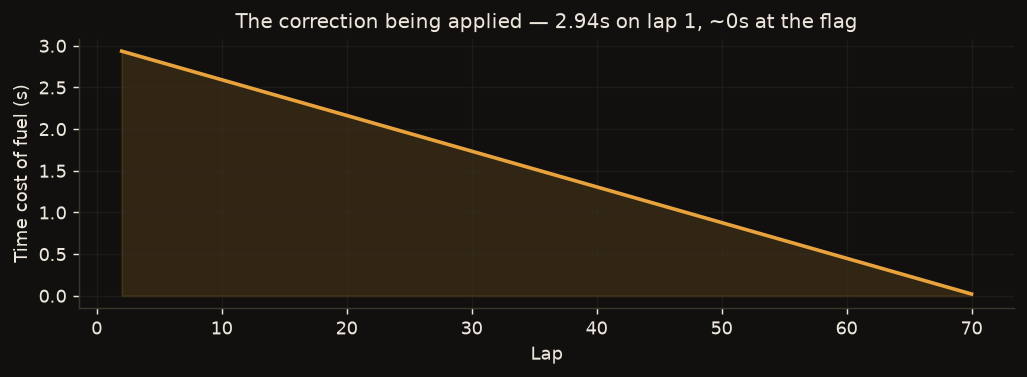

In [5]:
laps = pace.fuel_correct(laps, session.total_laps)

fig, ax = plt.subplots(figsize=(8, 3))
by_lap = laps.groupby("LapNumber")["FuelPenaltyS"].first()
ax.plot(by_lap.index, by_lap.values, color=plots.ACCENT, linewidth=2)
ax.fill_between(by_lap.index, 0, by_lap.values, color=plots.ACCENT, alpha=0.15)
ax.set_xlabel("Lap"); ax.set_ylabel("Time cost of fuel (s)")
ax.set_title(f"The correction being applied — {by_lap.iloc[0]:.2f}s on lap 1, "
             f"~0s at the flag", fontsize=11)
plt.tight_layout(); plt.show()

## 4. Who was actually fast?

Median rather than mean, deliberately. Even after cleaning, the residual noise in lap times
is **one-sided** — a lap can be ruined, but it cannot accidentally be fast. A mean would drag
every driver toward whoever had the worst luck in traffic.

In [6]:
ranking = pace.pace_ranking(laps)
ranking.round(3)

,Rank,Driver,Team,CleanLaps,MedianPace,BestPace,IQR,GapS,GapPct
0,1,NOR,McLaren,64,81.580,80.777,1.058,0.000,0.000
1,2,PIA,McLaren,64,81.635,80.747,1.321,0.055,0.068
2,3,HAM,Mercedes,64,81.894,80.994,0.809,0.314,0.385
3,4,LEC,Ferrari,64,82.084,80.403,0.815,0.505,0.619
4,5,VER,Red Bull Racing,64,82.165,80.072,1.225,0.585,0.718
5,6,SAI,Ferrari,64,82.200,80.678,0.973,0.620,0.761
6,7,PER,Red Bull Racing,64,82.549,80.175,1.722,0.970,1.189
7,8,RUS,Mercedes,64,82.581,79.641,1.351,1.001,1.227
8,9,ALO,Aston Martin,64,82.896,82.013,0.708,1.317,1.614
9,10,STR,Aston Martin,64,82.944,81.374,1.125,1.365,1.673


req            INFO 	Using cached data for driver_info


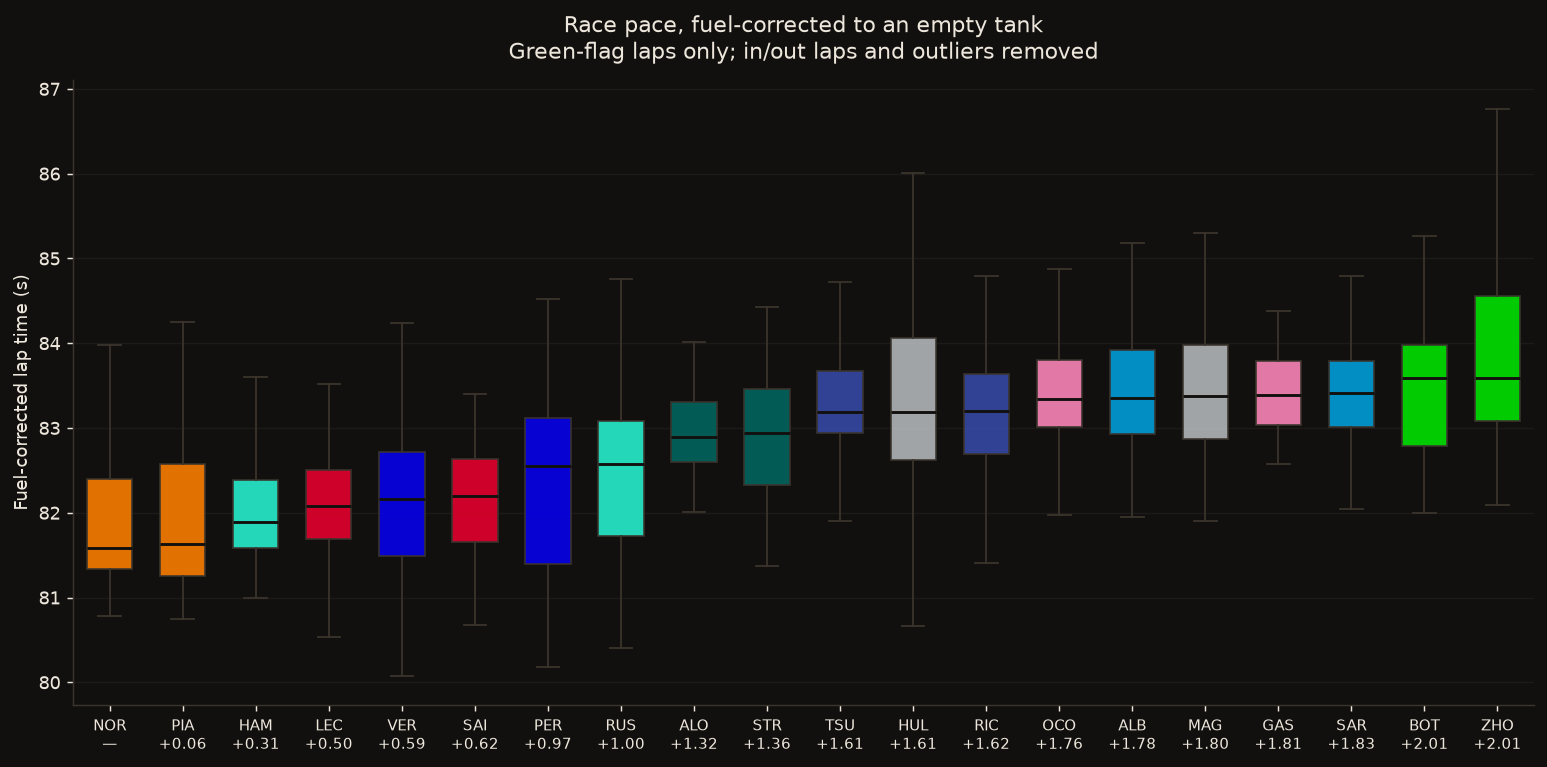

In [7]:
fig, ax = plt.subplots(figsize=(12, 6))
plots.plot_pace_ranking(laps, ranking, session, ax=ax)
plt.tight_layout(); plt.show()

The box plot is doing real work here. Two drivers can share a median and have had completely
different races — a tall box means the driver spent time in traffic, nursed a problem, or
was managing a tyre. A bar chart would have hidden that entirely.

## 5. But is any of that real?

This is the habit that separates a credible stats site from a dashboard.

Our pace numbers depend on a constant — 0.030 s/kg/lap — that is an *assumption*, not a
measurement. The plausible range is roughly 0.025 to 0.035. So: does the answer change if
the assumption is wrong?

In [8]:
sens = pace.fuel_sensitivity(clean.clean_laps(session), session.total_laps)
sens.round(2)

,Driver,rank@0.025,gap@0.025,rank@0.03,gap@0.03,rank@0.035,gap@0.035
0,NOR,1,0.00,1,0.00,1,0.00
1,PIA,2,0.07,2,0.06,2,0.07
2,HAM,3,0.29,3,0.31,3,0.30
3,LEC,4,0.48,4,0.50,4,0.53
4,VER,5,0.51,5,0.59,5,0.55
5,SAI,6,0.60,6,0.62,6,0.57
6,RUS,7,0.90,8,1.00,8,0.84
7,PER,8,1.02,7,0.97,7,0.80
8,ALO,9,1.25,9,1.32,10,1.24
9,STR,10,1.36,10,1.36,9,1.23


Read the three `rank@` columns across. Where the ordering holds steady, the result is a fact
about the race. Where it shuffles, the "result" was an artefact of a number we guessed — and
those drivers are genuinely too close to separate from one race.

**Report this, don't hide it.** Publishing your assumptions and their sensitivity is the single
cheapest way to be more trustworthy than every other F1 stats site.

## 6. Strategy

Ordered by finishing position, so you can read strategy and outcome together. The row that did
something different from the cars around it is the story of the race.

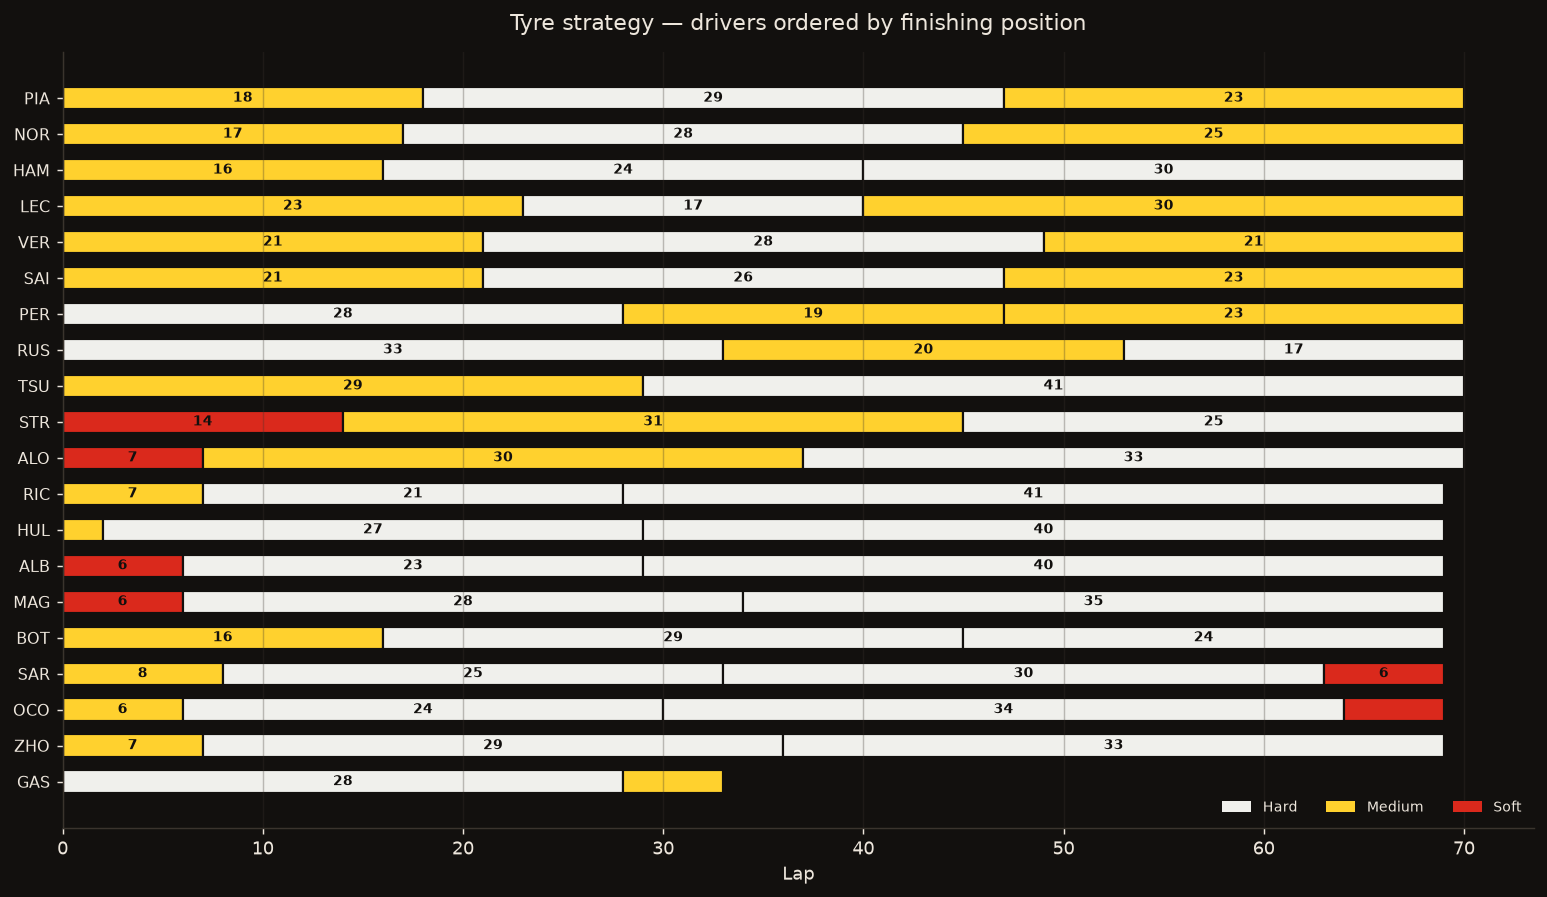

In [9]:
stints = clean.stint_table(session)
order = clean.finishing_order(session)

fig, ax = plt.subplots(figsize=(12, 7))
plots.plot_stint_gantt(stints, order, session, ax=ax)
plt.tight_layout(); plt.show()

## 7. Degradation — the input to a strategy simulator

Fit lap time against tyre age within each stint, with the fuel effect already removed. The
slope is the per-lap cost of staying out; the gap between compounds is what you gain by
switching.

Give a strategy simulator these slopes plus a pit-loss time and a safety car probability, and
it can answer "should they have gone for the two-stop?" — which is the most compelling feature
on your race-companion list.

In [10]:
deg = pace.degradation(laps)
deg.round(3).head(12)

,Driver,Team,Stint,Compound,Laps,DegSPerLap,DegStdErr,R2,FreshPaceS
0,ALB,Williams,2,HARD,21,0.094,0.015,0.662,82.122
1,ALB,Williams,3,HARD,38,0.080,0.013,0.520,82.204
2,ALO,Aston Martin,1,SOFT,5,-0.096,0.132,0.151,83.799
3,ALO,Aston Martin,2,MEDIUM,28,0.020,0.013,0.077,82.669
4,ALO,Aston Martin,3,HARD,31,0.076,0.011,0.619,81.851
5,BOT,Kick Sauber,1,MEDIUM,14,-0.071,0.030,0.323,83.514
6,BOT,Kick Sauber,2,HARD,27,0.041,0.015,0.228,83.148
7,BOT,Kick Sauber,3,HARD,21,0.110,0.045,0.239,82.800
8,GAS,Alpine,1,HARD,26,0.023,0.012,0.140,83.160
9,HAM,Mercedes,1,MEDIUM,14,0.057,0.017,0.479,81.357


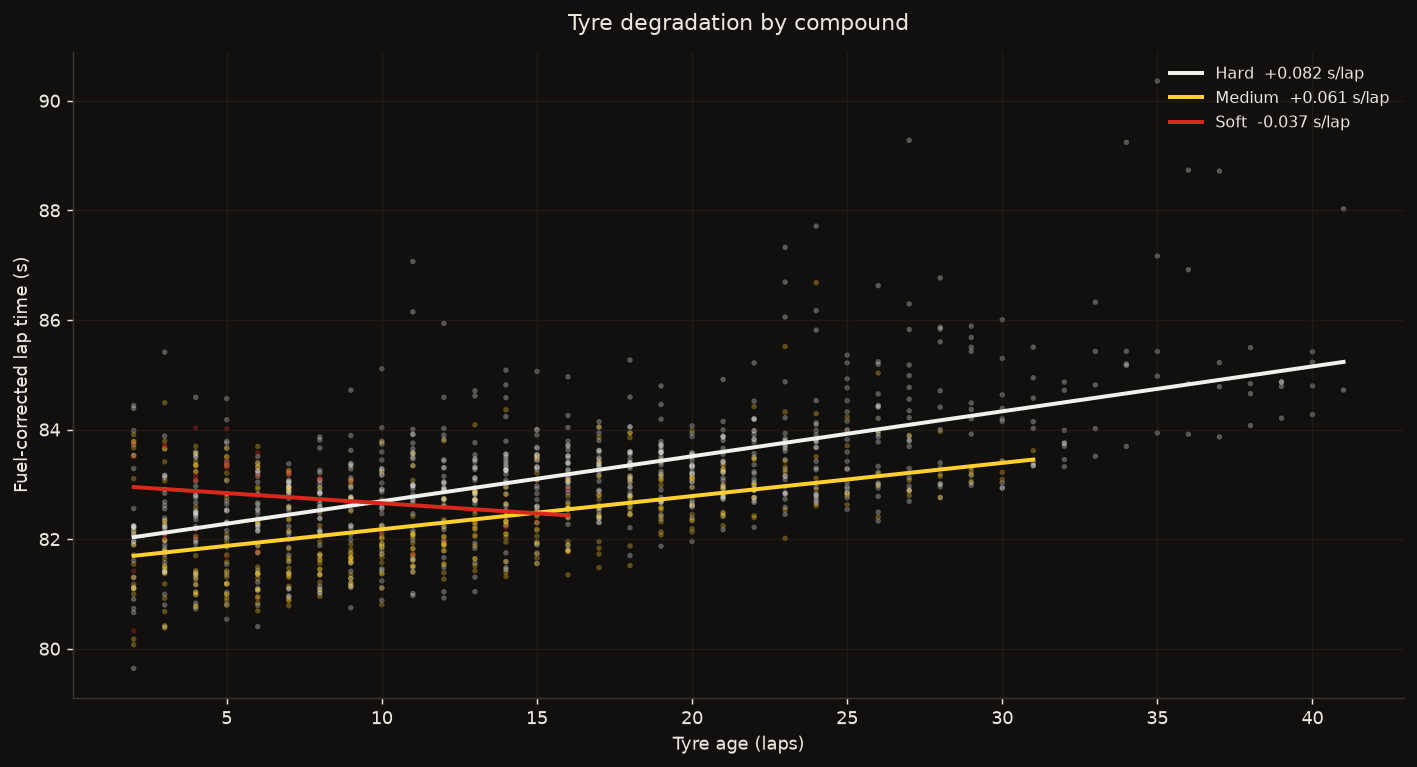

In [11]:
fig, ax = plt.subplots(figsize=(11, 6))
plots.plot_degradation(laps, deg, session, ax=ax)
plt.tight_layout(); plt.show()

### Read the anomaly before you trust the chart

Look at the fitted slopes. At least one compound will often come out **negative** — tyres
apparently getting *faster* as they age, which is not a thing.

That is not a bug, it is confounding, and it is worth understanding now rather than after you
have shipped it:

- The soft tyre is usually run in **short stints early in the race**, when the track is still
  rubbering in and every lap is genuinely quicker than the last
- So the pooled fit is measuring **track evolution**, not degradation, and track evolution is
  the larger effect over those laps
- The hard tyre is usually run **long and late**, when the track is at its best — so its slope
  is closer to true degradation

Fixing this means putting track evolution in the model as its own term rather than letting it
hide inside the tyre-age coefficient. That is the same modelling instinct the driver-vs-car
problem needs, on an easier problem. It is a genuinely good place to cut your teeth.

Meanwhile, the per-stint `DegStdErr` column in the table above is your guard rail: a
confident-looking slope fitted to six noisy laps is not a finding.

## 8. Teammate deltas — the bridge to driver-vs-car

Teammates share a car. So the gap between them is the cleanest estimate of driver effect you
can get **without modelling anything at all**.

Percent rather than seconds, because a tenth at Monaco and a tenth at Spa are not the same
amount of driving.

In [12]:
deltas = pace.teammate_deltas(ranking)
deltas.round(3)

,Team,Faster,Slower,GapS,GapPct,LapsCompared
0,Mercedes,HAM,RUS,0.687,0.839,64
1,Red Bull Racing,VER,PER,0.384,0.468,64
2,Haas F1 Team,HUL,MAG,0.195,0.234,63
3,Ferrari,LEC,SAI,0.116,0.141,64
4,McLaren,NOR,PIA,0.055,0.068,64
5,Williams,ALB,SAR,0.055,0.066,61
6,Aston Martin,ALO,STR,0.048,0.058,64
7,Alpine,OCO,GAS,0.048,0.057,29
8,RB,TSU,RIC,0.017,0.021,63
9,Kick Sauber,BOT,ZHO,0.001,0.001,62


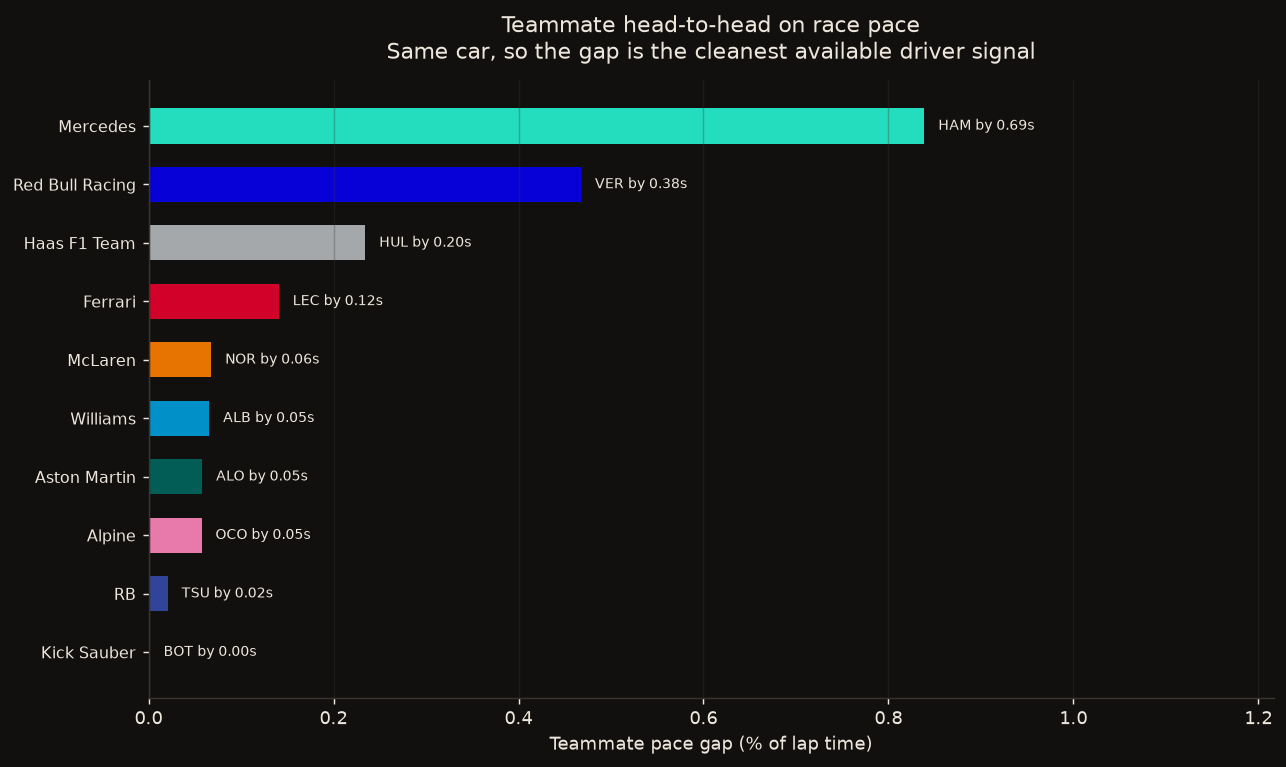

In [13]:
fig, ax = plt.subplots(figsize=(10, 6))
plots.plot_teammate_deltas(deltas, session, ax=ax)
plt.tight_layout(); plt.show()

### Why this single race is not the answer

Every number above is confounded. One driver may have had damage, run a different strategy,
spent the race in traffic, or been asked to hold station. Check the `LapsCompared` column — a
gap computed from a driver who retired at half distance is barely evidence at all.

The fix is not a better single-race statistic. It is **pooling**: gather these teammate pairs
across every race and every season, and let a hierarchical model separate the driver effect
from the car effect using the fact that drivers change teams and teammates over time. That is
the connected graph that makes the problem identifiable at all.

Roughly:

```
laptime ~ 1 + driver_effect[driver] + car_effect[constructor, season]
            + circuit_effect[circuit] + track_evolution + tyre_age + fuel
```

fitted as a Bayesian hierarchical model, so you get **credible intervals** rather than a
suspiciously precise point estimate. A driver with two seasons in one car should come out with
wide uncertainty, and the model should say so out loud.

Worth reading before you build it: Bell et al. (2016), *Formula for Success: Multilevel
Modelling of Formula One Driver and Constructor Performance* — it solves exactly this and
gives you a baseline to check yourself against.

---

## Where to go from here

**Immediate, to find out if you enjoy this:** change `YEAR, GP` at the top and re-run on three
or four races you remember well. Do the pace rankings match your memory of those races? Where
they don't, figure out why. That disagreement is where you'll learn the most about the data.

**Then pick the next build step:**

*Toward the race companion:*
- Add pit-loss time per circuit and write a Monte Carlo one-stop vs two-stop simulator
- Add a safety car probability model, since SC timing dominates strategy outcomes more than
  degradation does

*Toward driver-vs-car:*
- Scale this pipeline to a full season, store the per-driver-per-race pace deltas in Postgres
- Fit the hierarchical model on multiple seasons with PyMC
- Start by reproducing a published result before trying to beat it

**Shared infrastructure both need:** a season-scale ingest that writes cleaned, corrected laps
to a database once, so nothing downstream ever recomputes this. That is the next real
engineering task, and it is worth doing before either model.